<a href="https://colab.research.google.com/github/shivaniyadav525/shivani_yadav/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum Cost Spanning Tree
Problem Description:
A spanning tree of a graph can be defined as a graph with minimal set of edges that connect all vertices. A minimum spanning tree of a graph is a spanning tree of the graph with least weight (where the weight is computed by adding the weights of all the edges in the spanning tree). In general, a graph can have multiple minimum spanning trees. The problem is to find a minimum spanning tree of a graph.

This implementation uses a dictionary to represent the weighted graph, where the vertices are keys, and the values are dictionaries containing their adjacent vertices and their weights.

Please note that this implementation assumes that the input graph is connected and weighted.

First, let's create a simple graph to demonstrate Prim's algorithm:

In [ ]:
graph = {
    "A": {"B": 10, "C": 15, "D": 20},
    "B": {"A": 10, "C": 12},
    "C": {"A": 15, "B": 12, "D": 18},
    "D": {"A": 20, "C": 18},
}


Now, let's implement Prim's algorithm:

In [2]:
def prim_algorithm(graph):
    min_tree = {}
    visited = set()
    min_tree[list(graph.keys())[0]] = []
    min_weight = 0

    while len(visited) < len(graph):
        min_edge = float('inf')
        next_vertex = None
        for vertex in min_tree:
            for adj_vertex, weight in graph[vertex].items():
                if adj_vertex not in visited:
                    if weight < min_edge:
                        min_edge = weight
                        next_vertex = adj_vertex

        min_tree[next_vertex] = []
        visited.add(next_vertex)
        min_weight += min_edge

    return min_tree, min_weight

Now, let's run the Prim's algorithm on the example graph:
Keep in mind that this example uses a simple representation of a graph, but for more complex cases, you might want to use a library such as NetworkX to represent and manipulate graphs.

In [8]:
mst, min_weight = prim_algorithm(graph)
print("Minimum Spanning Tree: ", mst)
print("Minimum Weight: ", min_weight)

AttributeError: 'list' object has no attribute 'items'

Take Differnt example of input graph as discussed in lecture slide and use above code to verify the output

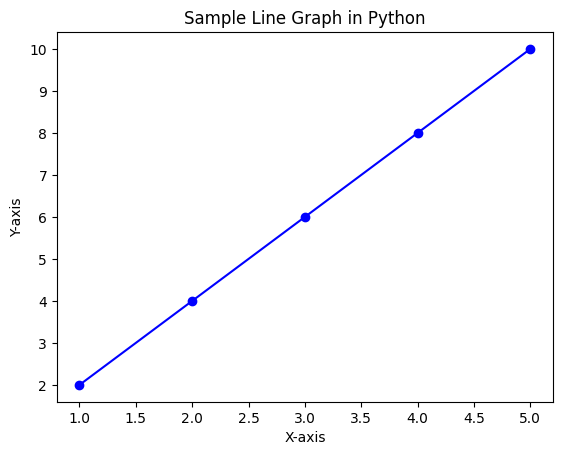

In [7]:
# your sample input of graph
import matplotlib.pyplot as plt


x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]


plt.plot(x, y, marker='o', linestyle='-', color='b')

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Sample Line Graph in Python")


plt.show()


In [5]:
#run prims algorithm for sample input
import heapq

def prims_algorithm(graph, start):
    visited = set()
    mst = []
    edges = [(0, start, start)]

    while edges:
        weight, frm, to = heapq.heappop(edges)
        if to not in visited:
            visited.add(to)
            if frm != to:
                mst.append((frm, to, weight))

            for next_node, next_weight in graph[to]:
                if next_node not in visited:
                    heapq.heappush(edges, (next_weight, to, next_node))
    return mst

graph = {
    'A': [('B', 2), ('C', 3)],
    'B': [('A', 2), ('C', 1), ('D', 4)],
    'C': [('A', 3), ('B', 1), ('D', 5)],
    'D': [('B', 4), ('C', 5)]
}


mst = prims_algorithm(graph, 'A')

print("Minimum Spanning Tree (MST):")
for edge in mst:
    print(edge)


Minimum Spanning Tree (MST):
('A', 'B', 2)
('B', 'C', 1)
('B', 'D', 4)


Use same apporach for Kruskal's algorithm

In [6]:
# implement Kruskal's algorithm


class DisjointSet:
    def __init__(self, vertices):
        self.parent = {v: v for v in vertices}
        self.rank = {v: 0 for v in vertices}

    def find(self, v):
        if self.parent[v] != v:
            self.parent[v] = self.find(self.parent[v])
        return self.parent[v]

    def union(self, u, v):
        root_u = self.find(u)
        root_v = self.find(v)

        if root_u != root_v:
            if self.rank[root_u] < self.rank[root_v]:
                self.parent[root_u] = root_v
            elif self.rank[root_u] > self.rank[root_v]:
                self.parent[root_v] = root_u
            else:
                self.parent[root_v] = root_u
                self.rank[root_u] += 1


def kruskal(vertices, edges):

    edges = sorted(edges, key=lambda x: x[2])
    ds = DisjointSet(vertices)
    mst = []

    for u, v, weight in edges:
        if ds.find(u) != ds.find(v):
            ds.union(u, v)
            mst.append((u, v, weight))

    return mst


vertices = ['A', 'B', 'C', 'D']
edges = [
    ('A', 'B', 2),
    ('A', 'C', 3),
    ('B', 'C', 1),
    ('B', 'D', 4),
    ('C', 'D', 5)
]


mst = kruskal(vertices, edges)

print("Minimum Spanning Tree (MST):")
for edge in mst:
    print(edge)


Minimum Spanning Tree (MST):
('B', 'C', 1)
('A', 'B', 2)
('B', 'D', 4)
